# 13 — Dynamic Programming: Policy Evaluation
*Computing $v^\pi$ exactly from a known MDP model.*

**What you'll learn**

- How to evaluate a fixed policy using the Bellman expectation equation  
- The iterative policy evaluation algorithm (Dynamic Programming)  
- Synchronous vs in-place (asynchronous) sweeps and stopping criteria  
- Visualizing value functions on a small GridWorld  
- How DP policy evaluation connects to Monte Carlo and TD learning

> In DP, we assume *full knowledge of the MDP* and use Bellman backups to compute $v^\pi$ exactly (up to numerical tolerance).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Policy Evaluation via Bellman Expectation

For a fixed policy $ \pi $, the state-value function is

$$
v^\pi(s) = \mathbb{E}_\pi \big[ G_t \mid S_t = s \big]
= \mathbb{E}_\pi \big[ R_{t+1} + \gamma v^\pi(S_{t+1}) \mid S_t = s \big].
$$

Using the MDP model $p(s', r \mid s,a)$ and a stochastic policy $\pi(a\mid s)$:

$$
v^\pi(s)
= \sum_a \pi(a \mid s) \sum_{s',r}
   p(s', r \mid s,a) \big( r + \gamma v^\pi(s') \big).
$$

In vector form:

$$
v^\pi = r^\pi + \gamma P^\pi v^\pi.
$$

Solving exactly:

$$
v^\pi = (\mathbf{I} - \gamma P^\pi)^{-1} r^\pi
$$

works for small MDPs.  
Dynamic Programming (DP) instead applies the Bellman operator repeatedly:

$$
v_{k+1} = T^\pi v_k = r^\pi + \gamma P^\pi v_k,
$$

which converges to $ v^\pi $ because $T^\pi$ is a $\gamma$-contraction.

We’ll implement this for a small GridWorld.

In [3]:
# 4x4 GridWorld like in Sutton & Barto
# States: 0..15 laid out row-major
# 0 and 15 are terminal

GRID_H, GRID_W = 4, 4
num_states = GRID_H * GRID_W
ACTIONS = ["U", "D", "L", "R"]
num_actions = len(ACTIONS)

def to_rc(s):
    return divmod(s, GRID_W)

def to_s(r, c):
    return r * GRID_W + c

def step_gridworld(s, a):
    """Deterministic transition for the 4x4 GridWorld."""
    if s == 0 or s == num_states - 1:
        # Terminal stays terminal with 0 reward
        return s, 0.0, True

    r, c = to_rc(s)
    if a == 0:   # Up
        r2, c2 = max(r - 1, 0), c
    elif a == 1: # Down
        r2, c2 = min(r + 1, GRID_H - 1), c
    elif a == 2: # Left
        r2, c2 = r, max(c - 1, 0)
    elif a == 3: # Right
        r2, c2 = r, min(c + 1, GRID_W - 1)
    else:
        raise ValueError("invalid action index")

    s2 = to_s(r2, c2)

    # Reward: -1 per step until terminal, 0 at terminal
    done = (s2 == 0 or s2 == num_states - 1)
    rwd = 0.0 if done else -1.0

    return s2, rwd, done

# Build full transition model: P[s, a] → list of (p, s', r, done)
P_env = {}
for s in range(num_states):
    for a in range(num_actions):
        s2, r, done = step_gridworld(s, a)
        P_env[(s, a)] = [(1.0, s2, r, done)]

print("Example transitions from state 5:")
for a_idx, a_name in enumerate(ACTIONS):
    print(f"  action {a_name}: {P_env[(5, a_idx)]}")

Example transitions from state 5:
  action U: [(1.0, 1, -1.0, False)]
  action D: [(1.0, 9, -1.0, False)]
  action L: [(1.0, 4, -1.0, False)]
  action R: [(1.0, 6, -1.0, False)]


## 2. A Simple Policy on GridWorld

We’ll evaluate a uniform random policy:

$$
\pi(a \mid s) =
\begin{cases}
\frac{1}{4} & \text{if } s \text{ is non-terminal and } a \in \{\text{U,D,L,R}\} \\
1 & \text{if } s \text{ is terminal and } a = \text{(noop)} \\
\end{cases}
$$

In code, we simply choose each action with probability $1/4$ in non-terminal states.

In [4]:
gamma = 1.0  # standard setting for this GridWorld

def is_terminal(s):
    return s == 0 or s == num_states - 1

def uniform_policy(s):
    """Returns π(a|s) as an array of length num_actions."""
    if is_terminal(s):
        # Any action is irrelevant; value is 0 and staying put.
        return np.ones(num_actions) / num_actions
    return np.ones(num_actions) / num_actions

def bellman_expectation_backup(v, policy, gamma):
    """Apply the Bellman expectation update for all states under given policy."""
    v_new = np.zeros_like(v)
    for s in range(num_states):
        if is_terminal(s):
            v_new[s] = 0.0
            continue

        val = 0.0
        pi_s = policy(s)
        for a in range(num_actions):
            pi_sa = pi_s[a]
            for p, s2, r, done in P_env[(s, a)]:
                val += pi_sa * p * (r + gamma * v[s2])
        v_new[s] = val
    return v_new

In [5]:
def iterative_policy_evaluation(policy, gamma=1.0, theta=1e-4, max_iters=1000, inplace=False):
    """
    Evaluate a policy via iterative policy evaluation.
    - inplace=False: synchronous updates (v_{k+1} from v_k)
    - inplace=True: in-place updates (Gauss–Seidel style sweep)
    """
    v = np.zeros(num_states)
    history = [v.copy()]

    for it in range(max_iters):
        delta = 0.0
        if not inplace:
            # synchronous: compute v_new from old v
            v_new = bellman_expectation_backup(v, policy, gamma)
            delta = np.max(np.abs(v_new - v))
            v = v_new
        else:
            # in-place: update v[s] directly as we sweep
            for s in range(num_states):
                if is_terminal(s):
                    continue
                old_vs = v[s]

                val = 0.0
                pi_s = policy(s)
                for a in range(num_actions):
                    pi_sa = pi_s[a]
                    for p, s2, r, done in P_env[(s, a)]:
                        val += pi_sa * p * (r + gamma * v[s2])
                v[s] = val

                delta = max(delta, abs(old_vs - v[s]))

        history.append(v.copy())
        if delta < theta:
            break

    return np.array(history)

v_hist_sync = iterative_policy_evaluation(uniform_policy, gamma=gamma, theta=1e-4, inplace=False)
v_hist_inpl = iterative_policy_evaluation(uniform_policy, gamma=gamma, theta=1e-4, inplace=True)

print("Synchronous iterations:", len(v_hist_sync) - 1)
print("In-place iterations   :", len(v_hist_inpl) - 1)
print("Final v (sync):", np.round(v_hist_sync[-1], 3))

Synchronous iterations: 172
In-place iterations   : 114
Final v (sync): [  0.    -12.999 -18.998 -20.998 -12.999 -16.999 -18.998 -18.998 -18.998
 -18.998 -16.999 -12.999 -20.998 -18.998 -12.999   0.   ]


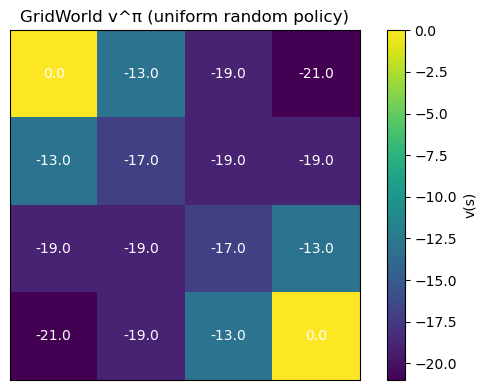

In [7]:
def plot_grid_values(v, title="State values"):
    grid = v.reshape(GRID_H, GRID_W)
    plt.figure(figsize=(6,4))
    plt.imshow(grid, cmap="viridis")
    for r in range(GRID_H):
        for c in range(GRID_W):
            plt.text(c, r, f"{grid[r, c]:.1f}",
                     ha="center", va="center", color="white", fontsize=10)
    plt.xticks([]); plt.yticks([])
    plt.title(title)
    plt.colorbar(label="v(s)")
    plt.tight_layout()
    plt.show()

plot_grid_values(v_hist_sync[-1], title="GridWorld v^π (uniform random policy)")

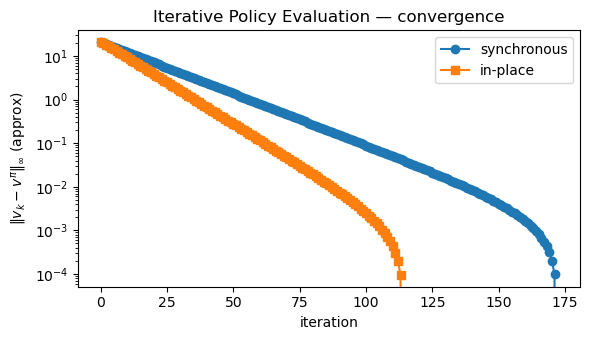

In [8]:
# Compare convergence: synchronous vs in-place (Gauss–Seidel)
sync_diff = np.linalg.norm(v_hist_sync - v_hist_sync[-1], ord=np.inf, axis=1)
inpl_diff = np.linalg.norm(v_hist_inpl - v_hist_inpl[-1], ord=np.inf, axis=1)

plt.figure(figsize=(6,3.5))
plt.plot(sync_diff, marker="o", label="synchronous")
plt.plot(inpl_diff, marker="s", label="in-place")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel(r"$\|v_k - v^\pi\|_\infty$ (approx)")
plt.title("Iterative Policy Evaluation — convergence")
plt.legend()
plt.tight_layout()
plt.show()

## 3. DP vs Monte Carlo vs Temporal-Difference

Dynamic Programming (DP) policy evaluation:

$$
v_{k+1}(s) = \sum_a \pi(a \mid s) \sum_{s',r}
              p(s',r \mid s,a) \big( r + \gamma v_k(s') \big)
$$

uses the full model $p(s',r \mid s,a)$ to update all states in sweeps.

Other families:

- **Monte Carlo (MC)**: estimate $ v^\pi(s) $ from sampled returns:
  $$
  v(s) \approx \frac{1}{N} \sum_{i=1}^N G^{(i)} \quad \text{from episodes starting in } s.
  $$
  No need for $p(\cdot)$, but must wait for episode termination.
- **Temporal-Difference (TD)**: bootstrap using a sampled next state:
  $$
  v(S_t) \leftarrow v(S_t) + \alpha \big( R_{t+1} + \gamma v(S_{t+1}) - v(S_t) \big).
  $$
  Uses *incomplete* returns and learns online.

**Big picture**

- DP: model-based, full sweeps, exact Bellman backups.  
- MC: model-free, full returns, high variance, but unbiased.  
- TD: model-free, bootstrapping, lower variance, bias–variance trade-off.

In all cases, the target is the same Bellman expectation equation for $v^\pi$ — only the way we approximate it differs.

## Key Takeaways

- Policy evaluation computes $ v^\pi $ for a fixed policy using the Bellman expectation equation:
  $$
  v^\pi(s) = \sum_a \pi(a \mid s) \sum_{s',r} p(s',r \mid s,a)\,
             \big( r + \gamma v^\pi(s') \big).
  $$
- Iterative policy evaluation (DP) repeatedly applies the Bellman operator across all states until the values converge within a tolerance.  
- Synchronous and in-place (Gauss–Seidel) sweeps both converge; in-place updates often converge faster in practice.  
- Visualizing $v^\pi$ on GridWorld makes it clear how values encode “distance-to-goal” under a policy.  
- Monte Carlo and TD methods approximate the same fixed point as DP, but without requiring access to the full MDP model.

**Next:** `14_dp_policy_iteration.ipynb` → use policy evaluation + greedy improvement to iteratively refine policies toward optimal control.